## Projeto de Análise Exploratória - Dados Contábeis

#### Pacotes

In [1]:
import pandas as pd
from scipy.stats import skew
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#### Carregando dados

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
df.shape

(1200, 11)

In [4]:
df.head()

,id,data_lancamento,conta_debito,conta_credito,valor,documento,natureza_operacao,centro_custo,impostos,moeda,taxa_conversao
0,1,2022-02-27,DWAVRL,CIOVQ6,5533.25,DOCPAXGQ,OP7JDVK,CC5FYA2,444.13252,NaN,3.475606
1,2,2022-05-11,D8TF53,CV9Y0V,7180.37,DOCBXZXG,OPXSY64,CCLH4R9,471.09236,EUR,3.523287
2,3,2020-03-23,D0TZCE,CELQSH,6067.36,DOCF5ITC,OPTDE9B,CCDG8CJ,326.49988,JPY,3.523287
3,4,2021-06-14,DOGLK7,CDFEMS,5494.34,DOCZRS1U,NaN,CC98G2K,471.09236,JPY,3.523287
4,5,2022-11-13,DHL0I5,CRU97G,4294.18,NaN,OP62LG1,CCZD80Y,154.26398,EUR,3.523287


In [5]:
df.columns

Index(['id', 'data_lancamento', 'conta_debito', 'conta_credito', 'valor',
       'documento', 'natureza_operacao', 'centro_custo', 'impostos', 'moeda',
       'taxa_conversao'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1200 non-null   int64  
 1   data_lancamento    1200 non-null   object 
 2   conta_debito       1200 non-null   object 
 3   conta_credito      1200 non-null   object 
 4   valor              1200 non-null   float64
 5   documento          1078 non-null   object 
 6   natureza_operacao  1080 non-null   object 
 7   centro_custo       1200 non-null   object 
 8   impostos           1020 non-null   float64
 9   moeda              947 non-null    object 
 10  taxa_conversao     982 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 103.3+ KB


### Análise Exploratória Inicial

In [7]:
sns.set(style = "whitegrid")

* Coluna **valor**

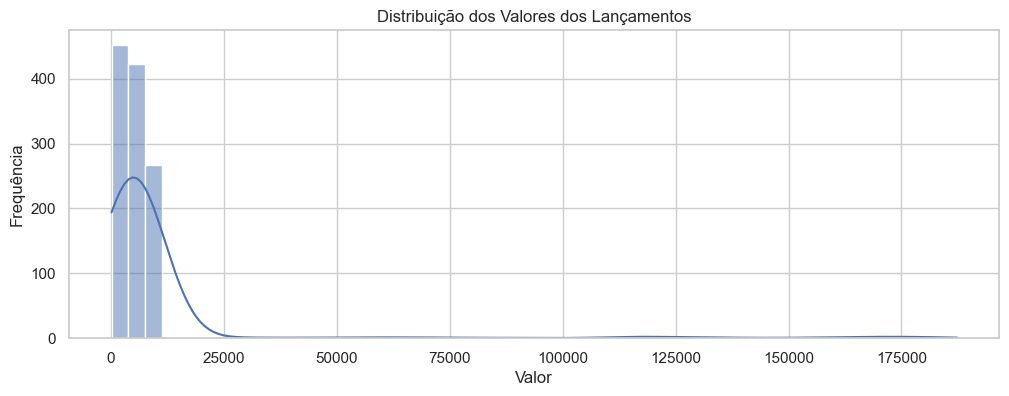

In [8]:
plt.figure(figsize = (12, 4))
sns.histplot(df['valor'], kde = True, bins = 50)
plt.title('Distribuição dos Valores dos Lançamentos')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

Maiora dos valores concentrados na região próxima de 0 e 20 mil. A linha de densidade continuando para valores altos dá indicios de presença de outliers na coluna <i>valor</i>.

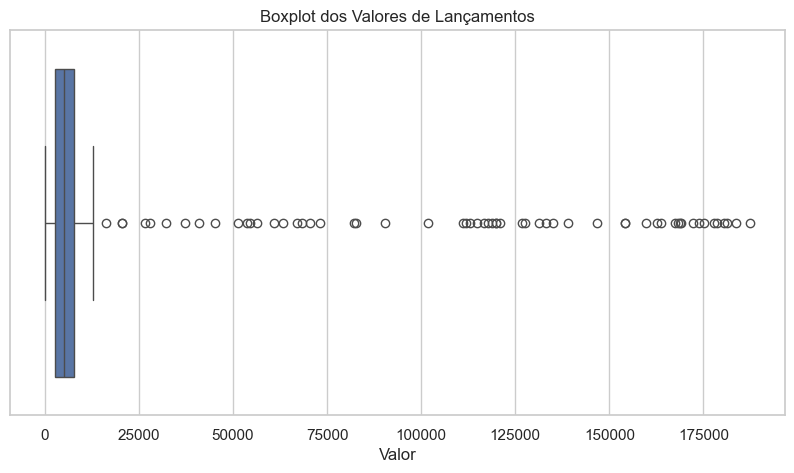

In [9]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = df['valor'])
plt.title('Boxplot dos Valores de Lançamentos')
plt.xlabel('Valor')
plt.show()

* Coluna **data_lancamento**

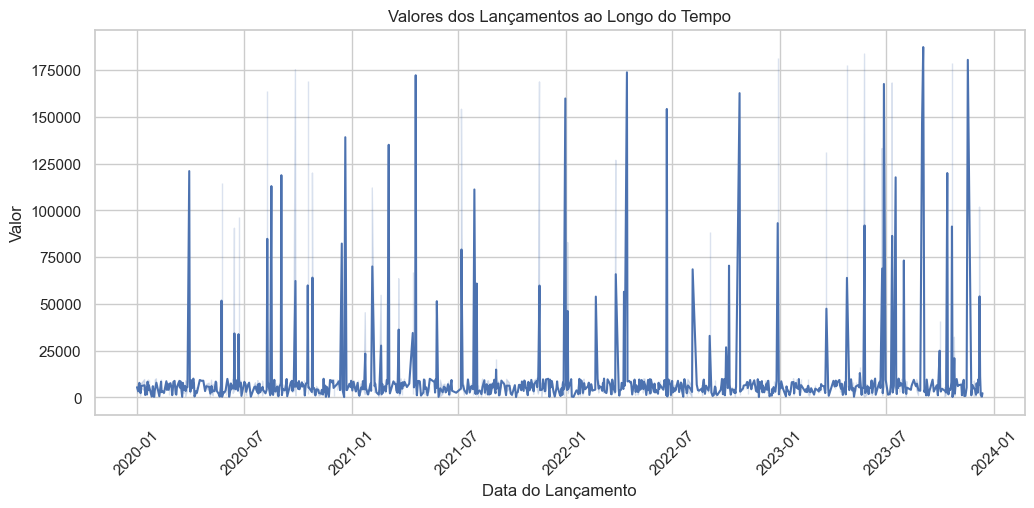

In [10]:
plt.figure(figsize = (12, 5))
sns.lineplot(x = pd.to_datetime(df['data_lancamento']), y = 'valor', data = df)
plt.title('Valores dos Lançamentos ao Longo do Tempo')
plt.xlabel('Data do Lançamento')
plt.ylabel('Valor')
plt.xticks(rotation = 45)
plt.show()

* Coluna **impostos**

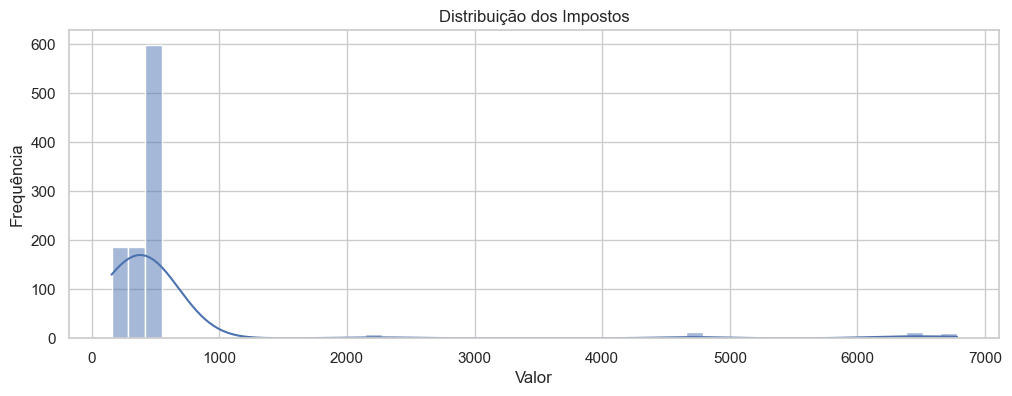

In [11]:
plt.figure(figsize = (12, 4))
sns.histplot(df['impostos'], kde = True, bins=50)
plt.title('Distribuição dos Impostos')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

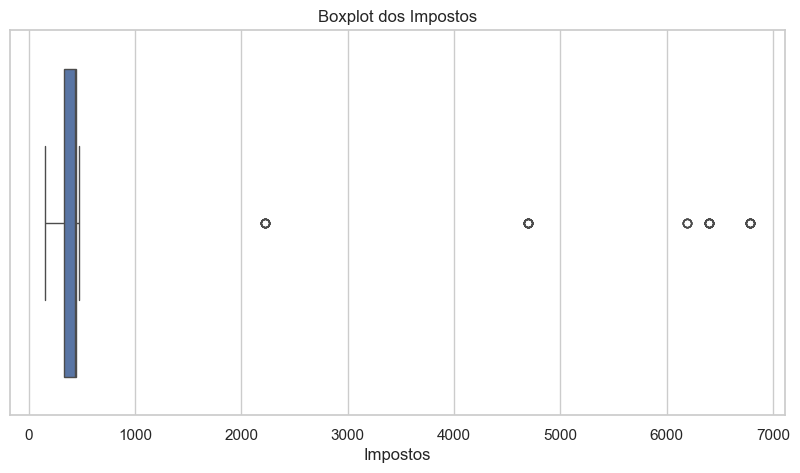

In [12]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = df['impostos'])
plt.title('Boxplot dos Impostos')
plt.xlabel('Impostos')
plt.show()

Mediana bem achatada e alguns outliers bem distante da distribuição.

* Coluna **moeda**

In [13]:
contagem_moedas = df['moeda'].value_counts(dropna=False)

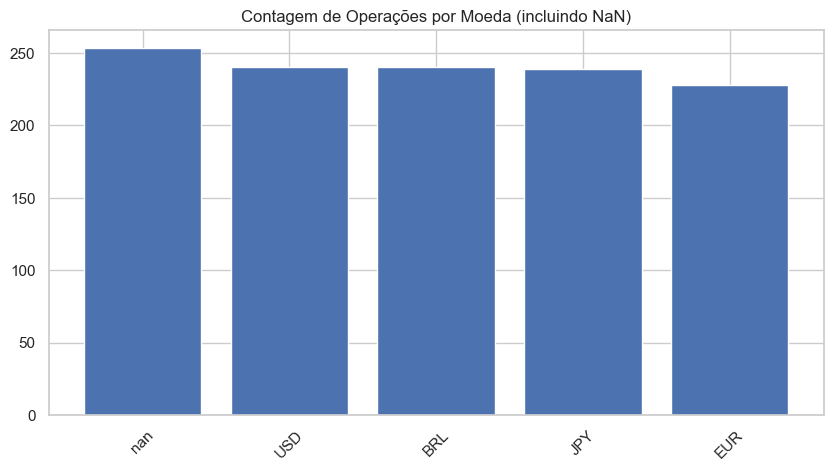

In [14]:
plt.figure(figsize=(10,5))
plt.bar(contagem_moedas.index.astype(str), contagem_moedas.values)
plt.xticks(rotation=45)
plt.title('Contagem de Operações por Moeda (incluindo NaN)')
plt.show()

* Coluna **taxa_conversao**

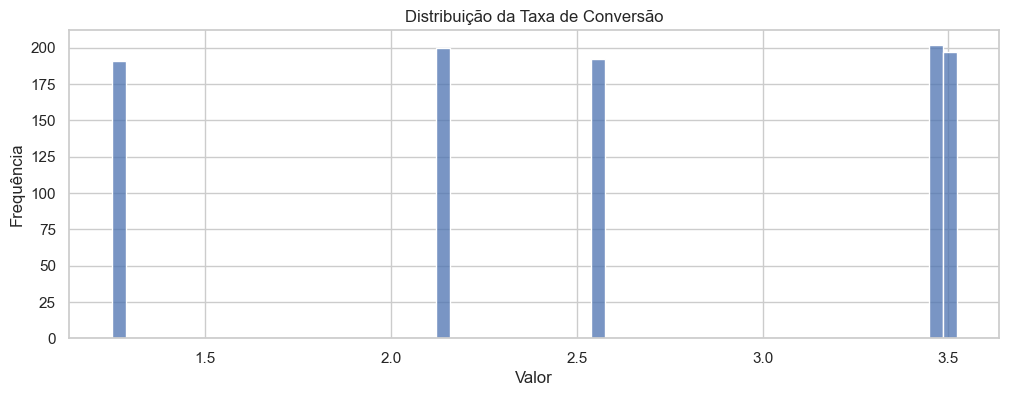

In [15]:
plt.figure(figsize = (12, 4))
sns.histplot(df['taxa_conversao'], bins = 60)
plt.title('Distribuição da Taxa de Conversão')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show()

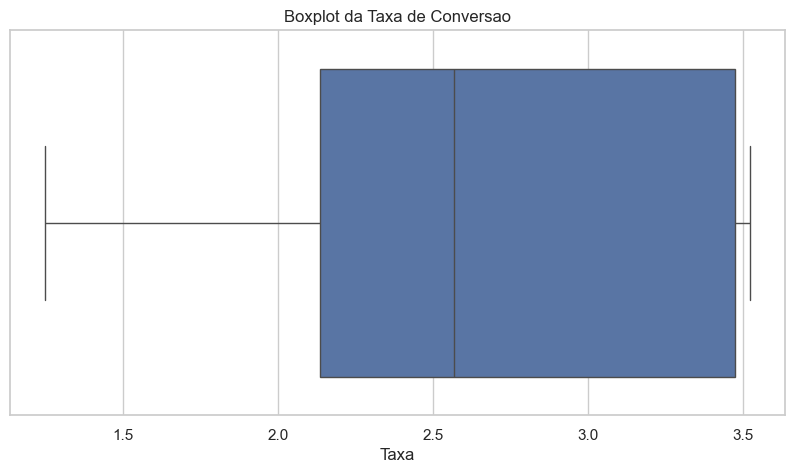

In [16]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = df['taxa_conversao'])
plt.title('Boxplot da Taxa de Conversao')
plt.xlabel('Taxa')
plt.show()

### Pré-processamento

**Duplicatas**

In [17]:
duplicatas = df.duplicated()

In [18]:
df[duplicatas]

,id,data_lancamento,conta_debito,conta_credito,valor,documento,natureza_operacao,centro_custo,impostos,moeda,taxa_conversao


Nenhuma linha duplicada.

**Valores negativos**

In [19]:
df.describe()

,id,valor,impostos,taxa_conversao
count,1200.000000,1200.000000,1020.000000,982.000000
mean,600.500000,10094.975148,604.264546,2.601499
std,346.554469,25595.942955,1116.015868,0.853906
min,1.000000,105.410000,154.263980,1.248029
25%,300.750000,2631.245000,326.499880,2.135300
50%,600.500000,5092.510000,430.155339,2.568117
75%,900.250000,7881.407500,444.132520,3.475606
max,1200.000000,187297.686041,6779.970522,3.523287


Não é preciso tratar, pois não há valores negativos errôneos.

**Valores Ausentes**

In [20]:
def calc_percent_valores_ausentes(df):
    total_celulas = np.prod(df.shape)
    contagem_ausentes = df.isnull().sum()
    total_ausentes = contagem_ausentes.sum()
    print("O dataset possui", round(((total_ausentes/total_celulas) * 100), 2), "%", "de valores ausentes.")

In [21]:
calc_percent_valores_ausentes(df)

O dataset possui 6.77 % de valores ausentes.


In [22]:
def calc_percent_valores_ausentes_coluna(df):
    contagem_ausentes = df.isnull().sum()
    contagem_ausentes_percentagem = 100 * contagem_ausentes / len(df)
    contagem_ausentes_dtype = df.dtypes
    tabela_contagem_ausentes = pd.concat([contagem_ausentes, contagem_ausentes_percentagem, contagem_ausentes_dtype], axis=1)
    tabela_contagem_ausentes.rename(columns = {0 : 'Valores Ausentes', 1 : '% de Valores Ausentes', 2: 'Dtype'}, inplace=True)
    tabela_contagem_ausentes = tabela_contagem_ausentes[tabela_contagem_ausentes.iloc[:,0] != 0].sort_values(
        '% de Valores Ausentes', ascending = False).round(2)
    print ("O dataset possui " + str(df.shape[1]) + " colunas.\n"
        "Encontrado: " + str(tabela_contagem_ausentes.shape[0]) + " colunas que têm valores ausentes.")
    if tabela_contagem_ausentes.shape[0] == 0:
        return
    return tabela_contagem_ausentes

In [23]:
calc_percent_valores_ausentes_coluna(df)

O dataset possui 11 colunas.
Encontrado: 5 colunas que têm valores ausentes.


,Valores Ausentes,% de Valores Ausentes,Dtype
moeda,253,21.08,object
taxa_conversao,218,18.17,float64
impostos,180,15.00,float64
documento,122,10.17,object
natureza_operacao,120,10.00,object


In [24]:
df['impostos'].fillna(df['impostos'].median(), inplace=True)

A distribuição da coluna taxa_conversao não apresenta valores contínuos e uniformes. Possui uma distribuição bem diferente da coluna de impostos. Irei preencher os valores ausentes por moda para evitar inserir valores novos que não existem fora das faixas de taxa encontradas no gráfico, mantendo assim valores já existentes.

In [25]:
df['taxa_conversao'].fillna(df['taxa_conversao'].mode()[0], inplace=True)

In [26]:
calc_percent_valores_ausentes_coluna(df)

O dataset possui 11 colunas.
Encontrado: 3 colunas que têm valores ausentes.


,Valores Ausentes,% de Valores Ausentes,Dtype
moeda,253,21.08,object
documento,122,10.17,object
natureza_operacao,120,10.00,object


In [27]:
df['moeda'].fillna('Não informado', inplace=True)

In [28]:
df['documento'].fillna('Não informado', inplace=True)

In [29]:
df['natureza_operacao'].fillna('Não informado', inplace=True)

In [30]:
calc_percent_valores_ausentes_coluna(df)

O dataset possui 11 colunas.
Encontrado: 0 colunas que têm valores ausentes.


**Valores errôneos**

In [31]:
df.select_dtypes(include='object')

,data_lancamento,conta_debito,conta_credito,documento,natureza_operacao,centro_custo,moeda
0,2022-02-27,DWAVRL,CIOVQ6,DOCPAXGQ,OP7JDVK,CC5FYA2,Não informado
1,2022-05-11,D8TF53,CV9Y0V,DOCBXZXG,OPXSY64,CCLH4R9,EUR
2,2020-03-23,D0TZCE,CELQSH,DOCF5ITC,OPTDE9B,CCDG8CJ,JPY
3,2021-06-14,DOGLK7,CDFEMS,DOCZRS1U,Não informado,CC98G2K,JPY
4,2022-11-13,DHL0I5,CRU97G,Não informado,OP62LG1,CCZD80Y,EUR
...,...,...,...,...,...,...,...
1195,2023-04-25,DZ081E,C5QNDG,DOCQTVSP,OPLQ42Z,CCS2L4D,Não informado
1196,2020-09-28,D01L23,C8FEYD,DOC1Z4VO,OP6CBY4,CCUMRRS,JPY
1197,2023-07-12,D9YZNN,CXYME9,Não informado,OPBHEQV,CCGSXK6,EUR
1198,2022-10-17,D5BQW4,CKSB0T,DOCZGO9C,OPC3Q46,CCOWC3N,JPY


In [32]:
labels_valores_erroneos = ['undefined', 'n/a', '?']

In [33]:
colunas_categoricas = df.select_dtypes(include = ['object', 'category']).columns

In [34]:
def detectar_valores_erroneos(df, colunas, valores_errados):
    mascara_erronea = df[colunas].isin(valores_errados)
    mascara_linhas_erradas = mascara_erronea.any(axis=1)
    return df[mascara_linhas_erradas]

In [35]:
df_erros = detectar_valores_erroneos(df, colunas_categoricas, labels_valores_erroneos)

In [36]:
df_erros

,id,data_lancamento,conta_debito,conta_credito,valor,documento,natureza_operacao,centro_custo,impostos,moeda,taxa_conversao
22,23,2021-09-27,DBOEMB,?,4668.65,DOCIP6VJ,OPUGAEB,CCVPFJ0,430.155339,BRL,2.135300
28,29,2023-02-20,D3VBFM,?,5266.30,DOCS1RZH,OPFA004,CC9GD1L,326.499880,USD,3.475606
35,36,2021-02-22,DLA23K,?,6214.59,DOCTRWRX,OPQJ46R,CCAM30Y,471.092360,USD,3.475606
74,75,2021-11-12,DBS4CM,?,7418.71,DOCPCF91,OPWKNUE,CCZCE75,471.092360,EUR,3.475606


Apenas a coluna <i>conta_credito</i> possui valores a serem tratados.\
Estes registros serão salvos para caso mude como devem ser tratados e também para encaminhar para análise do que poderia ser.

In [37]:
df_erros.to_csv('registros_com_problemas.csv', index=False)

In [38]:
df['conta_credito'] = df['conta_credito'].replace('?', 'Desconhecido')

In [39]:
detectar_valores_erroneos(df, colunas_categoricas, labels_valores_erroneos)

,id,data_lancamento,conta_debito,conta_credito,valor,documento,natureza_operacao,centro_custo,impostos,moeda,taxa_conversao


Dataset limpo.

**Outliers**

Foi indicado para remover os outliers presentes na coluna de impostos, aparentando ser erros de digitação, e valores acima de 50.000 da coluna valor.

In [40]:
df.shape

(1200, 11)

In [41]:
Q1 = df['impostos'].quantile(0.25)
Q3 = df['impostos'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
df_limpo = df[~((df['impostos'] < limite_inferior) | (df['impostos'] > limite_superior))]

In [42]:
df_limpo.shape

(1151, 11)

In [43]:
df_limpo = df_limpo[df_limpo['valor'] <= 30000]

In [44]:
df_limpo.shape

(1100, 11)

### Análise Exploratória Depois da Limpeza

In [45]:
contagem_moedas = df_limpo['moeda'].value_counts(dropna=False)

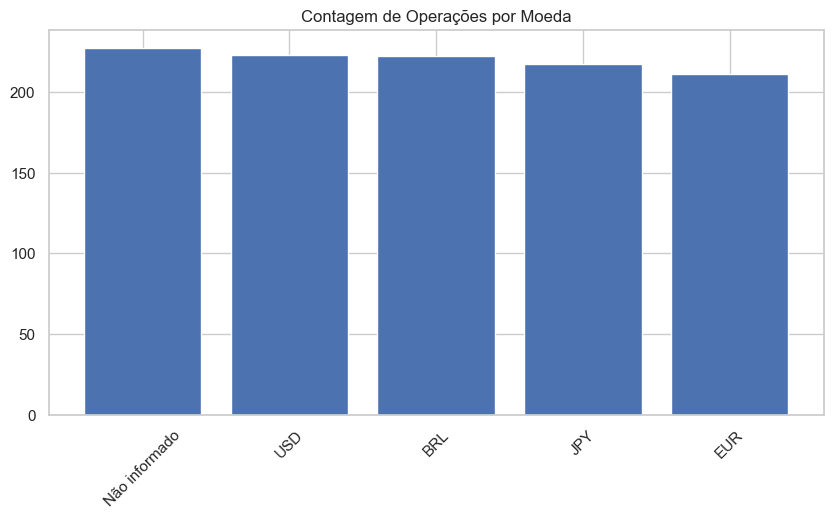

In [81]:
plt.figure(figsize=(10,5))
plt.bar(contagem_moedas.index.astype(str), contagem_moedas.values)
plt.xticks(rotation=45)
titulo = plt.title('Contagem de Operações por Moeda')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

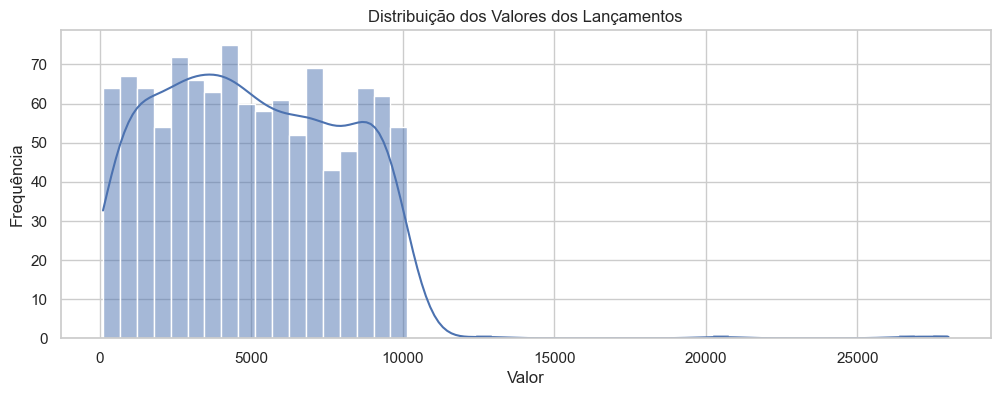

In [82]:
plt.figure(figsize = (12, 4))
sns.histplot(df_limpo['valor'], kde = True, bins = 50)
titulo = plt.title('Distribuição dos Valores dos Lançamentos')
plt.xlabel('Valor')
plt.ylabel('Frequência')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

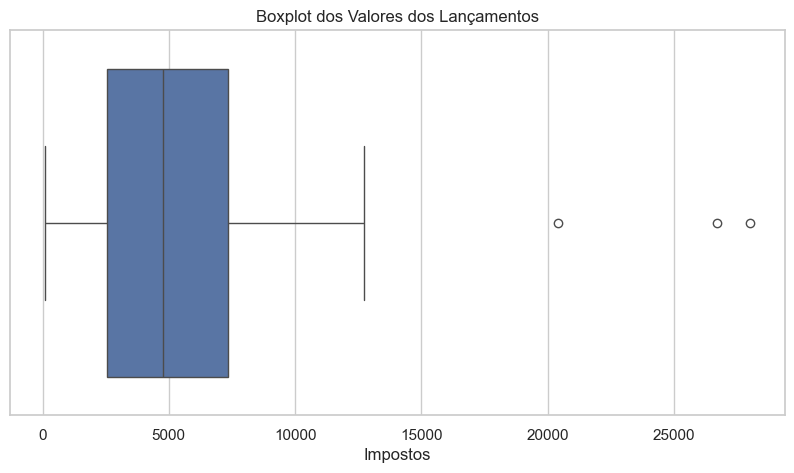

In [85]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = df_limpo['valor'])
titulo = plt.title('Boxplot dos Valores dos Lançamentos')
plt.xlabel('Impostos')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

A presença menor de barras isoladas agora permite visualizar onda há maior concentração e variança de valor. 

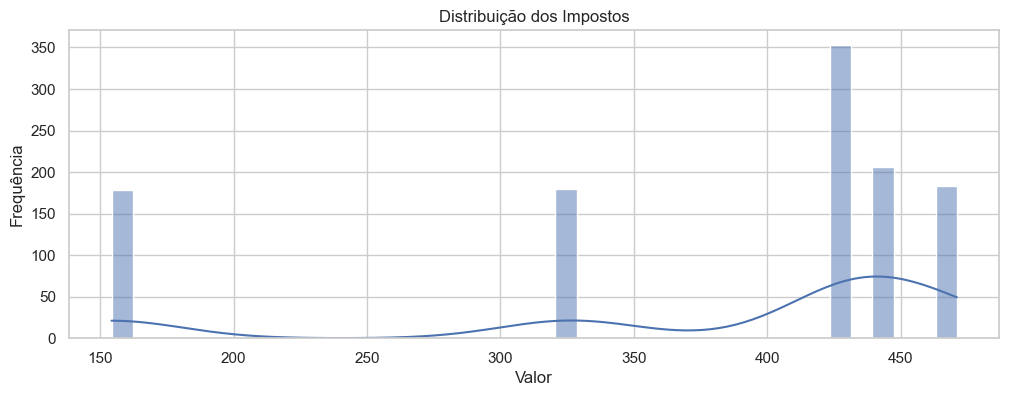

In [86]:
plt.figure(figsize = (12, 4))
sns.histplot(df_limpo['impostos'], kde = True, bins=40)
titulo = plt.title('Distribuição dos Impostos')
plt.xlabel('Valor')
plt.ylabel('Frequência')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

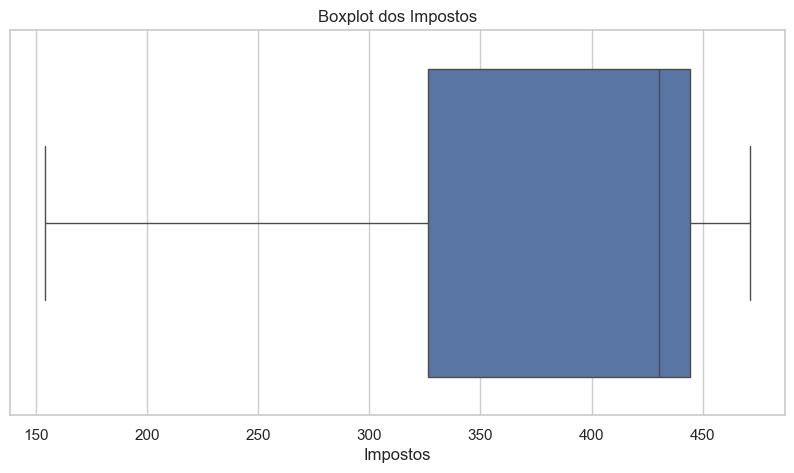

In [78]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = df_limpo['impostos'])
titulo = plt.title('Boxplot dos Impostos')
plt.xlabel('Impostos')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

In [51]:
skewness = skew(df['impostos'])
print(f"A assimetria da distribuição dos valores é: {skewness}")

A assimetria da distribuição dos valores é: 5.125439220603724


In [52]:
skewness = skew(df_limpo['impostos'])
print(f"A assimetria da distribuição dos valores é: {skewness}")

A assimetria da distribuição dos valores é: -1.2694573513915102


Depois da etapa de pre-processamento a coluna de impostos passou a apresentar uma distribuição assímetrica positiva forte para uma distribuição assimétrica negativa moderada, diminuindo muito a variabilidade dos valores da coluna.

Identificamos a presença de grandes vales entre os valores de impostos

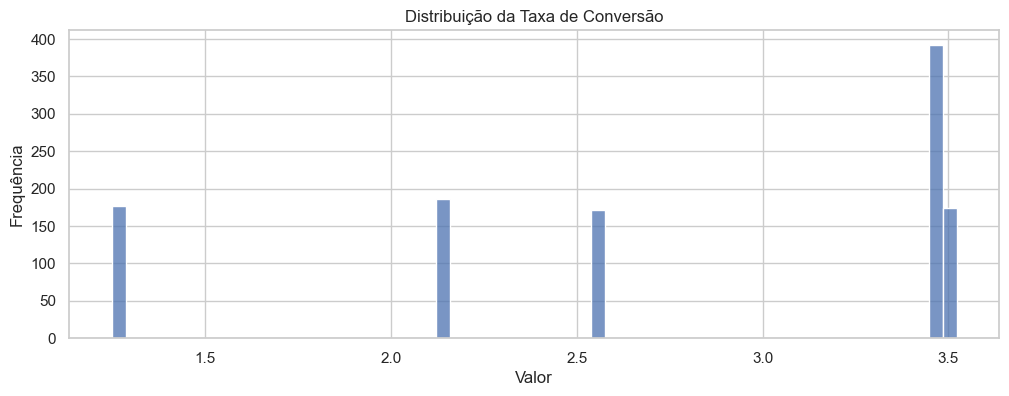

In [87]:
plt.figure(figsize = (12, 4))
sns.histplot(df_limpo['taxa_conversao'], bins = 60)
titulo = plt.title('Distribuição da Taxa de Conversão')
plt.xlabel('Valor')
plt.ylabel('Frequência')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

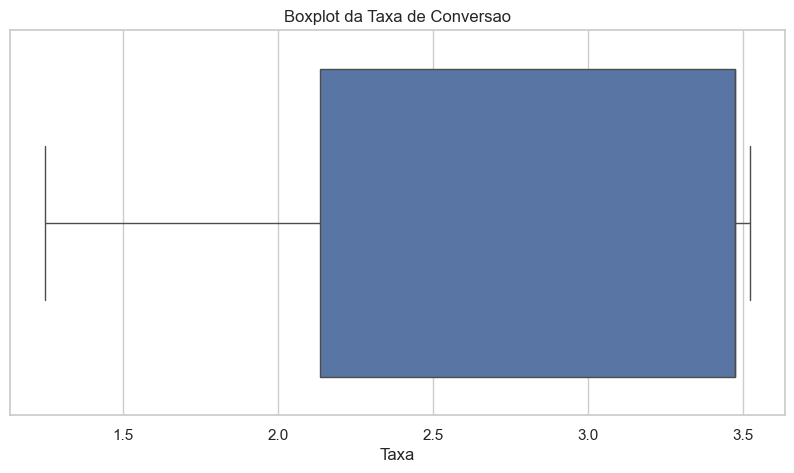

In [88]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = df_limpo['taxa_conversao'])
titulo = plt.title('Boxplot da Taxa de Conversao')
plt.xlabel('Taxa')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

In [55]:
df_limpo['taxa_conversao'].median()

3.475605626193917

Presença de grandes vales e faixas de valores de taxa de conversão bem definidos, com enfaze na região 3.5.\
E depois da limpeza a mediana passou de próximo de 2.5 a bem próximo do limite superior (3.47) do boxplot.

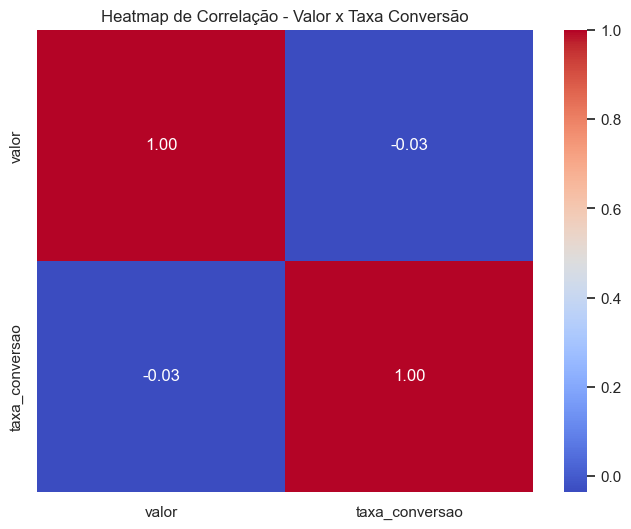

In [89]:
correlation_matrix = df_limpo[['valor', 'taxa_conversao']].corr()
plt.figure(figsize = (8, 6))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f")
titulo = plt.title("Heatmap de Correlação - Valor x Taxa Conversão")
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

Não existe correlação entre valor e taxa_conversao

In [57]:
df_limpo['data_lancamento'] = pd.to_datetime(df_limpo['data_lancamento'])

In [58]:
df_limpo['mes'] = df_limpo['data_lancamento'].dt.month

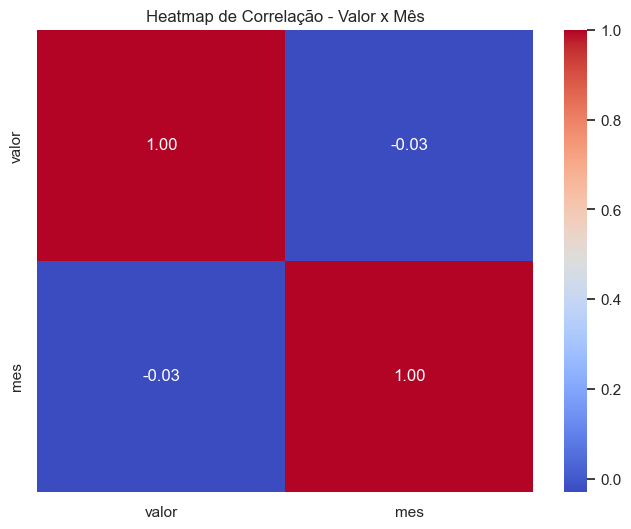

In [90]:
correlation_matrix = df_limpo[['valor', 'mes']].corr()
plt.figure(figsize = (8, 6))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f")
titulo = plt.title("Heatmap de Correlação - Valor x Mês")
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

Não foi identificado relação com o valor e os meses.

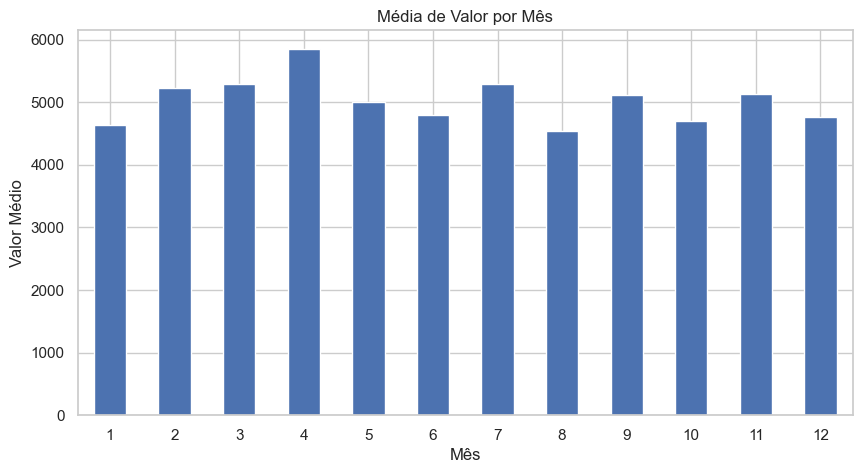

In [91]:
df_limpo.groupby('mes')['valor'].mean().plot(kind='bar', figsize=(10,5))
titulo = plt.title('Média de Valor por Mês')
plt.xlabel('Mês')
plt.ylabel('Valor Médio')
plt.xticks(rotation=0)
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

Mês de abril possui um valor médio um pouco maior que os outros meses.

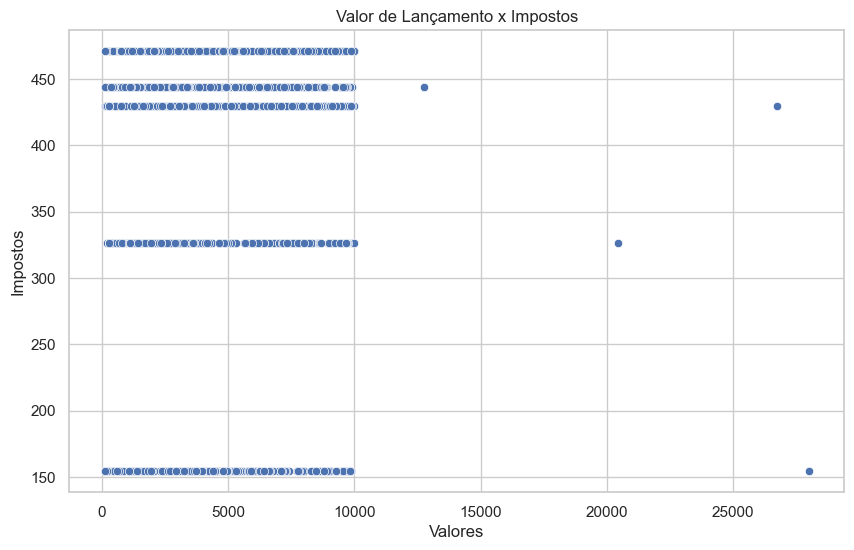

In [92]:
plt.figure(figsize = (10, 6))
sns.scatterplot(x = 'valor', y = 'impostos', data = df_limpo)
titulo = plt.title('Valor de Lançamento x Impostos')
plt.xlabel('Valores')
plt.ylabel('Impostos')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

Valor de impostos segue um padrão fixo devido a regras do tipo de transação.

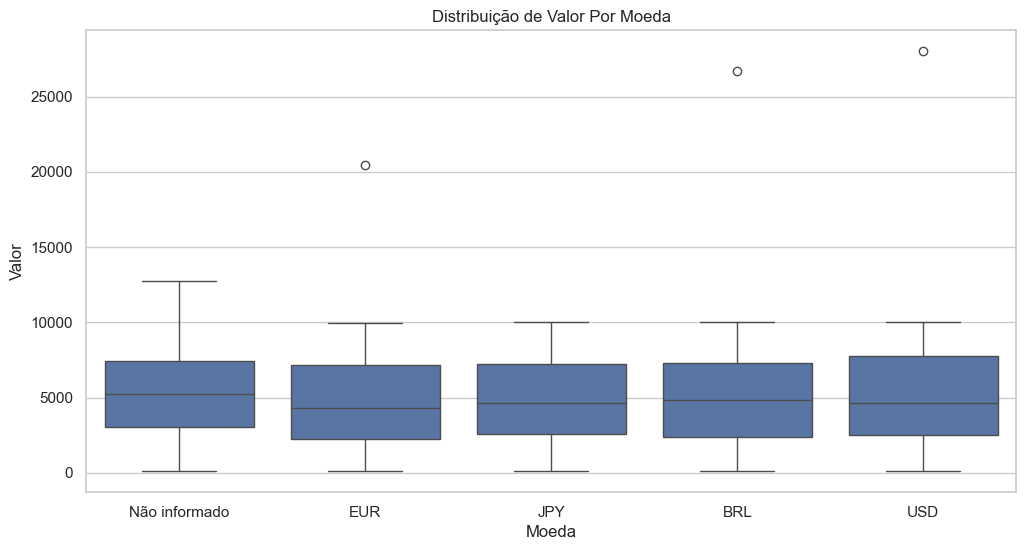

In [62]:
plt.figure(figsize = (12, 6))
sns.boxplot(x = 'moeda', y = 'valor', data = df_limpo)
plt.title('Distribuição de Valor Por Moeda')
plt.xlabel('Moeda')
plt.ylabel('Valor')
plt.show()

A maior dispersão de valores se encontra em lançamentos em que a moeda não foi informada.

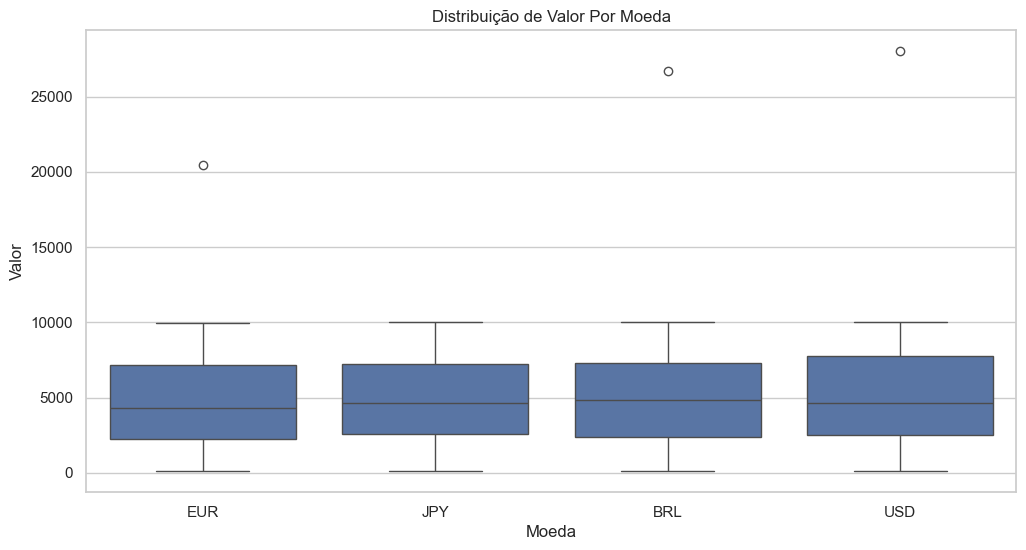

In [69]:
plt.figure(figsize = (12, 6))
sns.boxplot(x = 'moeda', y = 'valor', data = df_limpo[df_limpo['moeda'] != 'Não informado'])
titulo = plt.title('Distribuição de Valor Por Moeda')
plt.xlabel('Moeda')
plt.ylabel('Valor')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

A maior quantidade de valores acima da mediana se encontra em dólar.\
A mediana de lançamentos do EUR é a menor e a maior é de lançamentos em BRL.

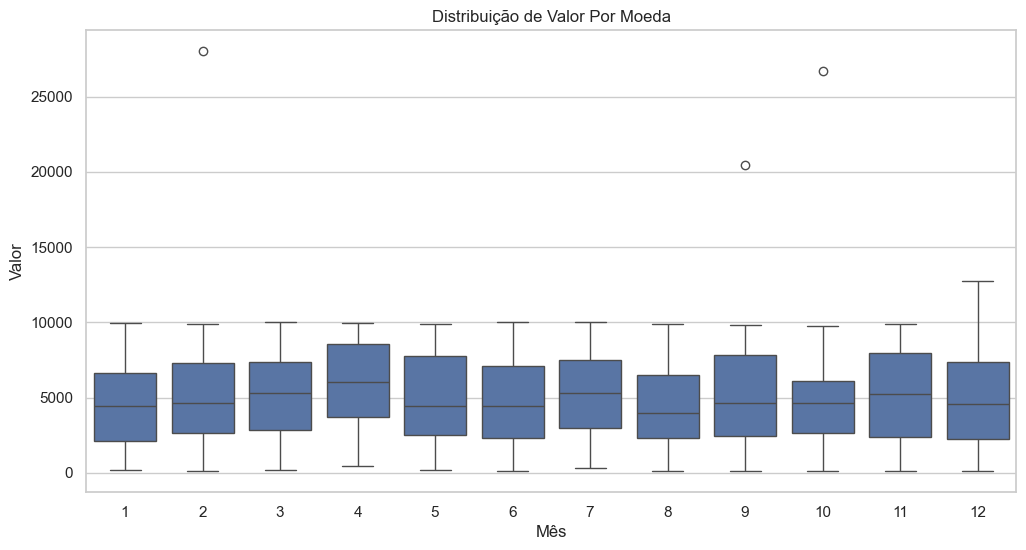

In [68]:
plt.figure(figsize = (12, 6))
sns.boxplot(x = 'mes', y = 'valor', data = df_limpo)
titulo = plt.title('Distribuição de Valor Por Moeda')
plt.xlabel('Mês')
plt.ylabel('Valor')
#plt.savefig(f"graficos/{titulo.get_text().replace(' ', '_') + '.png'}")
plt.show()

A menor mediana de valor se encontra no mês de Agosto (8).\
A maior variancia de valor de lançamentos ocorre no mês 12, dezembro, enquanto a menor no mês de outubro (10).